# 00 — SentinelPrompt overview

**Robustness of prompt-injection detectors against paraphrased, obfuscated and
Bangla–English code-mixed attacks.** CSE 4891 Data Mining, United International University.

This notebook gathers every model's results in one place. Run the others first:

| Notebook | What it does |
|---|---|
| `01_EDA` | looks at the data before modelling |
| `03_baselines` | TF-IDF + Logistic Regression, Naive Bayes, Linear SVM |
| `04_transformers` | DistilBERT, RoBERTa (fine-tuned), ProtectAI DeBERTa (zero-shot) |
| `05_robustness_analysis` | RDR, ASR, CLD, McNemar, dose-response, leakage ablation |
| `00_overview` | this notebook: all models side by side |

Every model uses the same splits, test sets and evaluation code (`src/evaluate.py`).

In [1]:
import os, sys, warnings
from pathlib import Path
if Path.cwd().name == "notebooks":        # run from the project root
    os.chdir("..")
sys.path.insert(0, "src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
plt.rcParams["figure.dpi"] = 80           # on-screen size only; saved PNGs are 300 dpi
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print("working directory:", Path.cwd().name)

working directory: sentinelprompt


### Test conditions

| ID | Test set | Rows | What it asks |
|---|---|---|---|
| **E1** | Test-Clean | 100 | How good is the model on unseen prompts like the training data? |
| **E2** | Test-Paraphrase | E1 rows reworded | Does the same attack, said differently, still get caught? |
| **E3** | Test-Obfuscated | 1,900 | Does it survive leetspeak, spacing, homoglyphs, zero-width, casing, typos, base64? |
| **E4** | Bangla–English (D4) | 900 | Does an English-trained model work on Bangla and code-mixed Bangla? |
| **E5** | Lakera | 1,000 | Does it catch attacks from a source it never saw? (all injections) |
| **FP** | PromptBench | 4,150 | Does it wrongly flag harmless task prompts? (all safe) |
| **E5x** | Lakera + PromptBench | 5,150 | E5 and FP pooled, so ROC-AUC and PR-AUC are defined |

E5 and FP each hold a single class. On those, macro-F1, ROC-AUC and PR-AUC are
undefined and shown as `NaN` on purpose; accuracy there equals recall (E5) or
specificity (FP). E5x pools them so the threshold-free metrics can be computed.

In [2]:
import evaluate as ev
parts = []
for f in ["metrics_baselines.csv", "metrics_transformers_summary.csv"]:
    p = Path("results/tables") / f
    if p.exists():
        parts.append(pd.read_csv(p))
    else:
        print(f"missing {p} -- run the notebook that produces it first")
allm = pd.concat(parts, ignore_index=True)
order = [c for c in ev.CONDITIONS if c in allm.condition.unique()]
allm.to_csv("results/tables/metrics_all_models.csv", index=False)
print(f"{allm.model.nunique()} models x {len(order)} conditions -> results/tables/metrics_all_models.csv")

6 models x 7 conditions -> results/tables/metrics_all_models.csv


## Macro-F1 — the primary metric (§3.12.2)
Rows are test conditions, columns are models. Transformer values are means over three seeds.

In [3]:
display(allm.pivot_table(index="condition", columns="model", values="macro_f1").reindex(order))

model,distilbert,linear_svm,logreg,naive_bayes,protectai_deberta,roberta
condition,,,,,,
E1_clean,0.9430,0.8886,0.9109,0.8663,0.7080,0.9777
E2_paraphrase,0.9290,0.8496,0.8496,0.8866,0.5726,0.9583
E3_obfuscated,0.7784,0.8547,0.8624,0.8474,0.6841,0.6924
E4_codemix,0.5910,0.6119,0.6421,0.7168,0.7763,0.5919
E5_crossdataset,NaN,NaN,NaN,NaN,NaN,NaN
FP_promptbench,NaN,NaN,NaN,NaN,NaN,NaN
E5x_pooled,0.1548,0.4223,0.3581,0.2004,0.9649,0.1554


## All metrics, all models

In [4]:
cols = ["model", "condition", "n", "accuracy", "precision", "recall", "specificity",
        "macro_f1", "mcc", "roc_auc", "pr_auc"]
display(allm[[c for c in cols if c in allm.columns]].sort_values(["condition", "model"],
        key=lambda s: s.map({c: i for i, c in enumerate(order)}) if s.name == "condition" else s))

,model,condition,n,accuracy,precision,recall,specificity,macro_f1,mcc,roc_auc,pr_auc
21,distilbert,E1_clean,100.0000,0.9500,0.9677,0.8824,0.9848,0.9430,0.8883,0.9874,0.9828
14,linear_svm,E1_clean,100.0000,0.9000,0.8529,0.8529,0.9242,0.8886,0.7772,0.9715,0.9391
0,logreg,E1_clean,100.0000,0.9200,0.8824,0.8824,0.9394,0.9109,0.8217,0.9728,0.9386
7,naive_bayes,E1_clean,100.0000,0.8800,0.8235,0.8235,0.9091,0.8663,0.7326,0.9340,0.9184
35,protectai_deberta,E1_clean,100.0000,0.7900,1.0000,0.3824,1.0000,0.7080,0.5386,0.8837,0.8592
28,roberta,E1_clean,100.0000,0.9800,0.9706,0.9706,0.9848,0.9777,0.9555,0.9952,0.9905
22,distilbert,E2_paraphrase,80.0000,0.9292,0.9833,0.8780,0.9829,0.9290,0.8652,0.9696,0.9793
15,linear_svm,E2_paraphrase,80.0000,0.8500,0.9143,0.7805,0.9231,0.8496,0.7089,0.9500,0.9569
1,logreg,E2_paraphrase,80.0000,0.8500,0.9143,0.7805,0.9231,0.8496,0.7089,0.9500,0.9581
8,naive_bayes,E2_paraphrase,80.0000,0.8875,1.0000,0.7805,1.0000,0.8866,0.7963,0.9043,0.9350


## Comparison charts

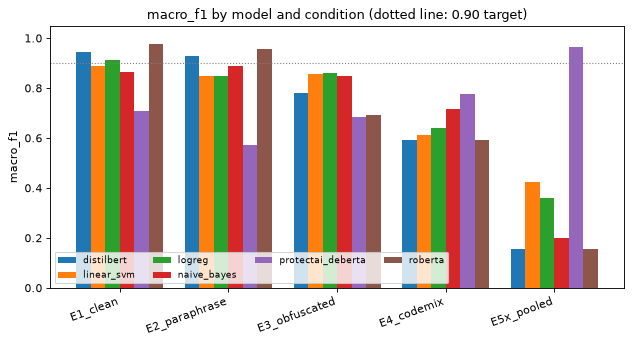

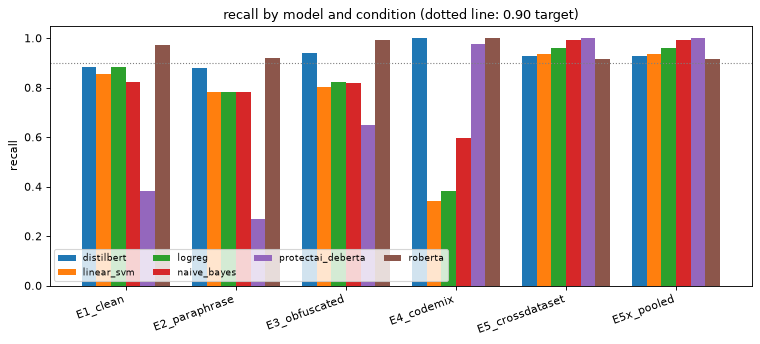

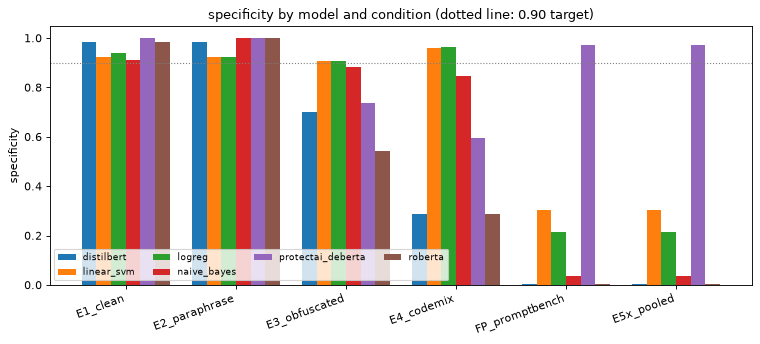

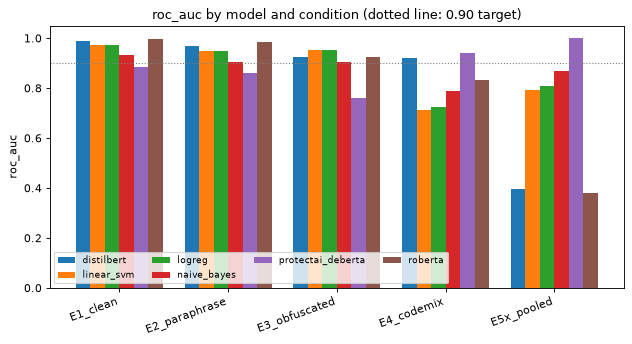

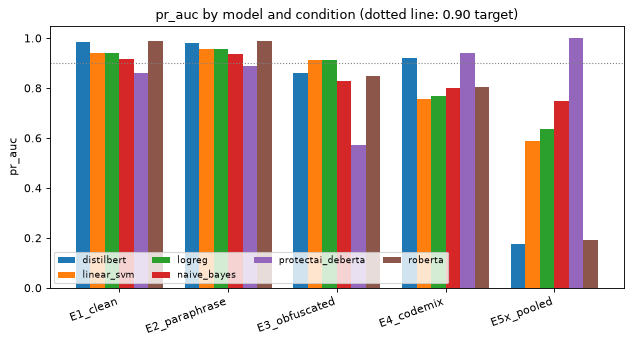

In [5]:
for m in ["macro_f1", "recall", "specificity", "roc_auc", "pr_auc"]:
    ev.comparison_chart(allm, m, name=f"overview_comparison_{m}"); plt.show()

## Accuracy above 97% — flagged

Any model/condition above the 97% guard is listed with the leakage check that ran at the time.

In [6]:
flags = [pd.read_csv(p) for p in Path("results/tables").glob("suspicious_accuracy_checks_*.csv")]
if flags:
    display(pd.concat(flags)[["model", "condition", "accuracy", "shared_groups", "exact_text_overlap",
                              "near_duplicates_in_train", "test_is_single_class"]])
else:
    print("no model exceeded 97% accuracy on any condition")

,model,condition,accuracy,shared_groups,exact_text_overlap,near_duplicates_in_train,test_is_single_class
0,naive_bayes,E5_crossdataset,0.9920,0,0,0,True
0,roberta,E1_clean,0.9900,0,0,0,False
1,roberta,E1_clean,0.9800,0,0,0,False
2,protectai_deberta,E5_crossdataset,1.0000,0,0,0,True
3,protectai_deberta,FP_promptbench,0.9716,0,0,0,True
4,protectai_deberta,E5x_pooled,0.9771,0,0,0,False


## Robustness summary (from notebook 05)

In [7]:
p = Path("results/tables/robustness_summary.csv")
if p.exists():
    rob = pd.read_csv(p)
    display(rob[[c for c in ["model", "E1_macro_f1", "E2_RDR_pct", "E2_ASR_pct", "E3_RDR_pct",
                             "E3_ASR_pct", "CLD_en_minus_bnen"] if c in rob.columns]])
else:
    print("run 05_robustness_analysis first")

,model,E1_macro_f1,E2_RDR_pct,E2_ASR_pct,E3_RDR_pct,E3_ASR_pct,CLD_en_minus_bnen
0,distilbert,0.9430,1.4708,4.5058,17.4388,0.0000,0.3770
1,linear_svm,0.8886,4.3853,8.8235,3.8169,8.3485,0.2338
2,logreg,0.9109,6.7242,11.4286,5.3260,8.7719,0.2157
3,naive_bayes,0.8663,-2.3458,5.8824,2.1818,3.5714,0.1062
4,protectai_deberta,0.7080,19.1137,21.4286,3.3733,6.4777,0.1017
5,roberta,0.9777,1.9698,5.7937,29.1506,0.3675,0.5724


## Headline numbers (computed)

In [8]:
pv = allm.pivot_table(index="model", columns="condition", values="macro_f1")
best = pv["E1_clean"].idxmax()
print(f"Best on clean data (E1): {best} with macro-F1 {pv.loc[best, 'E1_clean']:.3f}")
if "E4_codemix" in pv:
    drop = (pv["E1_clean"] - pv["E4_codemix"]).sort_values()
    print(f"Smallest E1 -> E4 (Bangla) drop: {drop.index[0]} ({drop.iloc[0]:+.3f}); "
          f"largest: {drop.index[-1]} ({drop.iloc[-1]:+.3f})")
fp = allm[allm.condition == "FP_promptbench"].set_index("model").specificity
print("False-positive rate on harmless PromptBench prompts:",
      ", ".join(f"{m} {1 - v:.2f}" for m, v in fp.items()))

Best on clean data (E1): roberta with macro-F1 0.978
Smallest E1 -> E4 (Bangla) drop: protectai_deberta (-0.068); largest: roberta (+0.386)
False-positive rate on harmless PromptBench prompts: logreg 0.79, naive_bayes 0.96, linear_svm 0.70, distilbert 1.00, roberta 1.00, protectai_deberta 0.03
